## Apresentação ✒️

Notebook destinado ao estudo de teste de hipótese aplicado ao monitoramento de data drifit, fenômeno relativo ao contexto de monitormaneto de aplicações baseadas em machine learning que busca compreender se os dados utilizados pelo modelo em sua etapa de treinamento apresentam característica similar - fazem parte da mesma distribuição - aos que ele irá ver em produção, cenário que é servido aos usuários. 

Tal monitoramento é importante, pois caso os dados para os quais o modelo é apresentado em produção divirja - drifit - daqueles vistos em treinamento, esse pode vir a apresentar uma piora em sua qualidade de inferência, prejudicando a experiência do usuário. Dessa forma, um dos caminhos que podem ser adotados para realizar tal observação se dá em verificar se ambos os dados - treino e produção - apresentam características estatísticas similares, como por exemplo a média. 

Uma forma leiga de se averiguar isso seria simplesmente selecionar ambos os dados e verificar a média dos valores de cada feature entre si, de tal modo que caso ambas fossem equivalentes ou muito semelhantes, poderia-se supor que fossem da mesma distribuição. Contudo, de pronto, com base nessa verificação, não podemos já supor que fazem parte da mesma distribuição, sendo salutar realizar tal suposição com base num nível de significância estatística que pode ser encontrado por meio dos testes de hipótese. 

Em virtude disso, será aplicado o uso de um modelo de classificação, de tal modo que será monitorado a qualidade de ajuste em dois tipos de datasets, comparando as métricas encontradas e depois averiguando se ambos fazem parte da mesma distribuição. O teste de hipótese será realizado com a estatística de teste z, utilizado para quando compreende-se que a quantidade de amostras é pelo menos superior a 30 e seguem uma distribuição normal. 

### Library 📚

In [73]:
import warnings
warnings.filterwarnings("ignore")

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pandas import DataFrame

from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scipy.stats import norm

### Carregando o dataset 💾

In [75]:
path = "data/star_classification.csv"

df_raw = pd.read_csv(path)

In [76]:
df_raw.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [77]:
df_raw["cam_col"].value_counts()

cam_col
4    19573
3    18851
5    18537
2    17117
1    13227
6    12695
Name: count, dtype: int64

In [78]:
df_raw = df_raw.drop(["obj_ID", "run_ID", "rerun_ID", "field_ID", "spec_obj_ID", "fiber_ID"], axis=1)

In [79]:
df_raw.shape

(100000, 12)

##### Verificando a integridade do dataset

In [80]:
df_raw.isnull().sum()

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
cam_col     0
class       0
redshift    0
plate       0
MJD         0
dtype: int64

In [81]:
df_raw.duplicated().sum()

np.int64(0)

In [82]:
df_raw.head()

,alpha,delta,u,g,r,i,z,cam_col,class,redshift,plate,MJD
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,GALAXY,0.634794,5812,56354
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,GALAXY,0.779136,10445,58158
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,GALAXY,0.644195,4576,55592
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,GALAXY,0.932346,9149,58039
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,GALAXY,0.116123,6121,56187


### Análise eploratória 🔬

Etapa em que, para fins desse notebook, verifica-se como os dados se encontram, verificando se apresentam bastante outliers e sua distribuição. A compreensão de ambos se faz necessária pois permite visualizar, no primeiro caso, se não é necessário realizar nenhuma processo de pré-tratamento antes dos dados serem colocados em um mesmo intervado e, no segundo, auxilia a concepção dos possíveis modelos a serem utilizados. Dessa forma, caso fosse por exemplo verificado uma distribuição linear das features em relação à label, poderia supor a utilização do modelo de regressão logística por exemplo. 

In [83]:
# Verificando a distribuição das classes no dataset

""" 
Analisando a quantidade de classes no dataset, nota-se que
elas se encontram desbalanceadas. Tal fato não é o recomendado
para passar ao modelo, uma vez que pode adicionar viés aos modelos, 
fazendo com que eles tenham maior tendência de classificar os dados
segundo à classe majoritária em detrimento da(s) classe(s) minoritária(s). 

Existem algumas alternativas para contornar tal cenário, mas, antes, deve-se
compreender o cenário no qual o(s) modelo(s) desenvolvido(s) se encontra(m), 
na forma em que se em produção as classes naturalmente são desbalanceadas 
se torna contraproducente realizar o balanceamento, sendo prefirível adotar
um sistema de maior penalização para os erros da classe minoritária.

Por outro lado, caso faça sentido realizar o balanceamento das classes, 
esse pode se dar segundo as seguintes estratégias principais :

- Adição da classe minoritária ao dataset
- Remoção da classe majoritária ao dataset
- Sintetização da classe minoritária ao dataset. 

Como o presente notebook não foca no processo de preparação dos 
dados, elaboração do modelo e avaliação como um todo, buscando
analisar o fenômeno do data drifit por meio de teste de hipótese, 
essa parte não será realizada. 
"""

df_raw["class"].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [84]:
# Definindo alguns parâmetros que serão passados para as funções a seguir. 

boxplot_parameters = {
    "style": "whitegrid", 
    "height": 12, 
    "width": 6,
    "bins": 35
}

winsorize_parameters = {
    "lower_percentile": 0.05, 
    "upper_percentile": 0.95
}

In [85]:
def boxplot(
        dataset: DataFrame, 
        style: str, 
        height: int, 
        width: int
    ):
    """
    Generates boxplots for each feature in the dataset. Automatically creates multiple
    figures if the number of features exceeds six.

    Parameters:
    ----------
    dataset : DataFrame
        The dataset to be visualized.
    style : str
        Seaborn theme for plot styling (e.g., 'darkgrid', 'whitegrid').
    height : int
        The height of the figure in inches.
    width : int
        The width of the figure in inches.
    """
    sns.set_theme(style=style)
    
    features = dataset.columns
    num_features = len(features)

    # Maximum number of subplots per figure
    features_per_figure = 6  

    # Ceil division
    num_figures = (num_features + features_per_figure - 1) // features_per_figure  
    
    for fig_idx in range(num_figures):
        # Determine the features for the current figure
        start = fig_idx * features_per_figure
        end = min(start + features_per_figure, num_features)
        current_features = features[start:end]
        
        # Create the figure
        plt.figure(figsize=(width, height))
        
        for i, feature in enumerate(current_features, 1):
            plt.subplot(2, 3, i)
            sns.boxplot(data=dataset[feature])
            plt.title(f"Boxplot de {feature}", rotation = 90)
        
        plt.tight_layout()
        plt.show()

In [86]:
X = df_raw.drop("class", axis=1)
y = df_raw["class"]

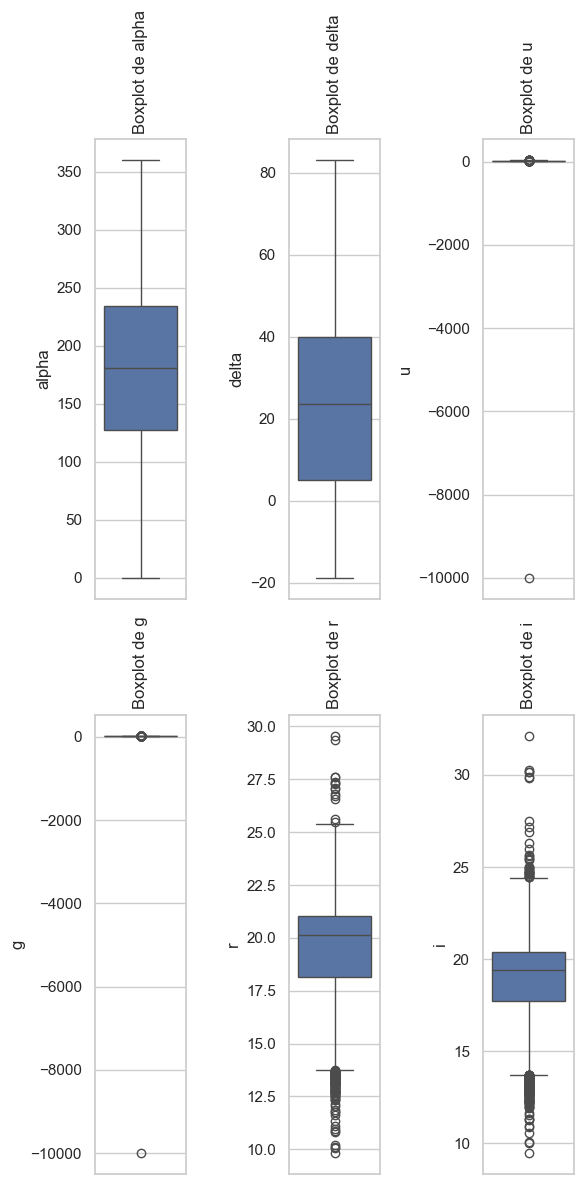

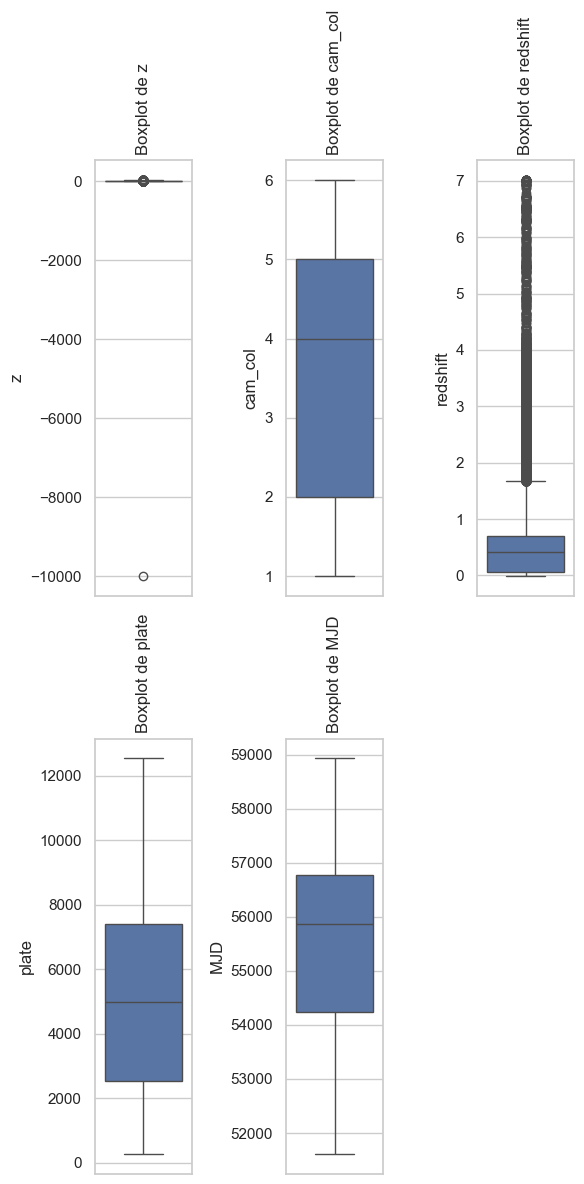

In [87]:
boxplot(
    dataset = X, 
    style   = boxplot_parameters["style"], 
    height  = boxplot_parameters["height"], 
    width   = boxplot_parameters["width"]
)

Verificando os gráficos de boxplot gerado correspondendo cada feature presente no dataset, nota-se que há a presença significativa de outliers, o que pode prejudicar a qualidade de ajuste do modelo de classificação utilizada. Nesse sentido, recomenda-se que em tais casos seja feito um tratamento dos outliers, visando diminuir o seu impacto, buscando um cenário de maior coesão. 

Existem *n* abordagens que podem ser adotadas para tanto, dentre as quais a transformação das features, fazendo com que se aproximem mais próximo de uma distribuição normal e por consequência diminuindo a quantidade de outliers, como também a remoção ou a técnica conhecida como winsorização, que se consiste em substituir os outliers pelos valores superiores ou inferiores de cada feature. 

A vantagem da winsorização é que ela não acarreta em perda de informação quando comparada com a simples remoção, caracterizando-se por substituir o valor dos termos compreendidos como outliers segundo o seu limite inferior ou superior. 

In [88]:
def wisonrize_function(
        dataset: DataFrame, 
        lower_percentile: float, 
        upper_percentile: float
):
    """ 
    Applies Winsorization to the DataFrame, capping extreme values based on specified percentiles.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing data to be winsorized.
        lower_percentile (float): The lower percentile threshold (e.g., 0.05 corresponds to the 5th percentile).
        upper_percentile (float): The upper percentile threshold (e.g., 0.95 corresponds to the 95th percentile).
    
    Returns:
        pd.DataFrame: A new DataFrame with winsorized values, where extreme values are replaced 
                      by the corresponding lower or upper percentile limits.
    """
    
    df_winsorized = dataset.copy()

    for column in dataset.columns:
        # Calculating limits
        lower_limit = np.percentile(dataset[column], lower_percentile * 100)
        upper_limit = np.percentile(dataset[column], upper_percentile * 100)

        # Applying Winsorization
        df_winsorized[column] = np.clip(dataset[column], lower_limit, upper_limit)
    
    return df_winsorized

In [89]:
X_winsorized = wisonrize_function(
    dataset          = X,
    lower_percentile = winsorize_parameters["lower_percentile"],
    upper_percentile = winsorize_parameters["upper_percentile"] 
    )

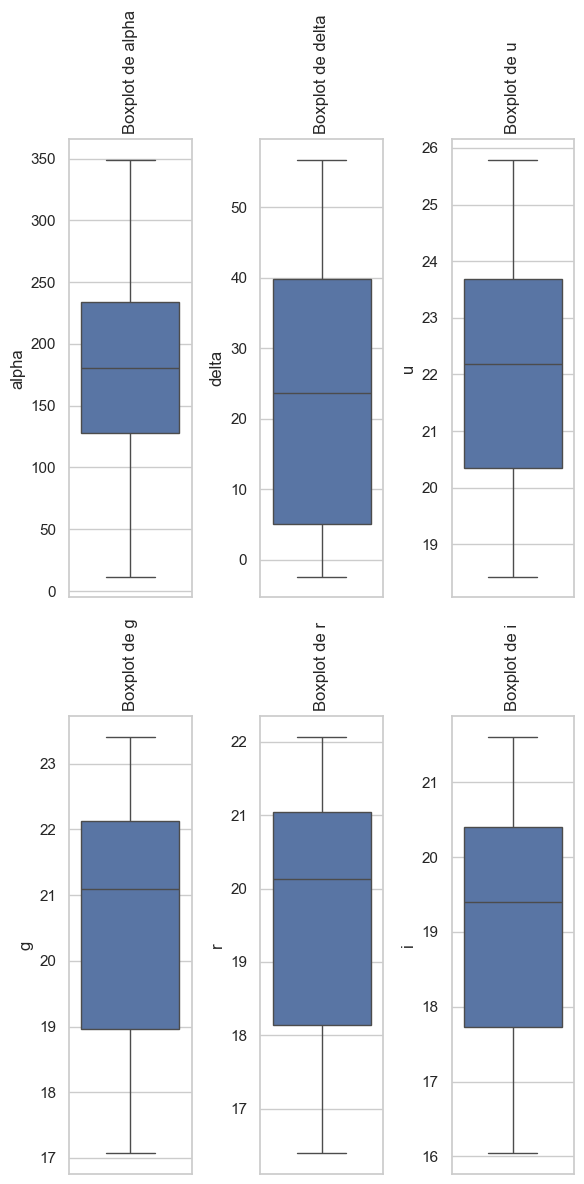

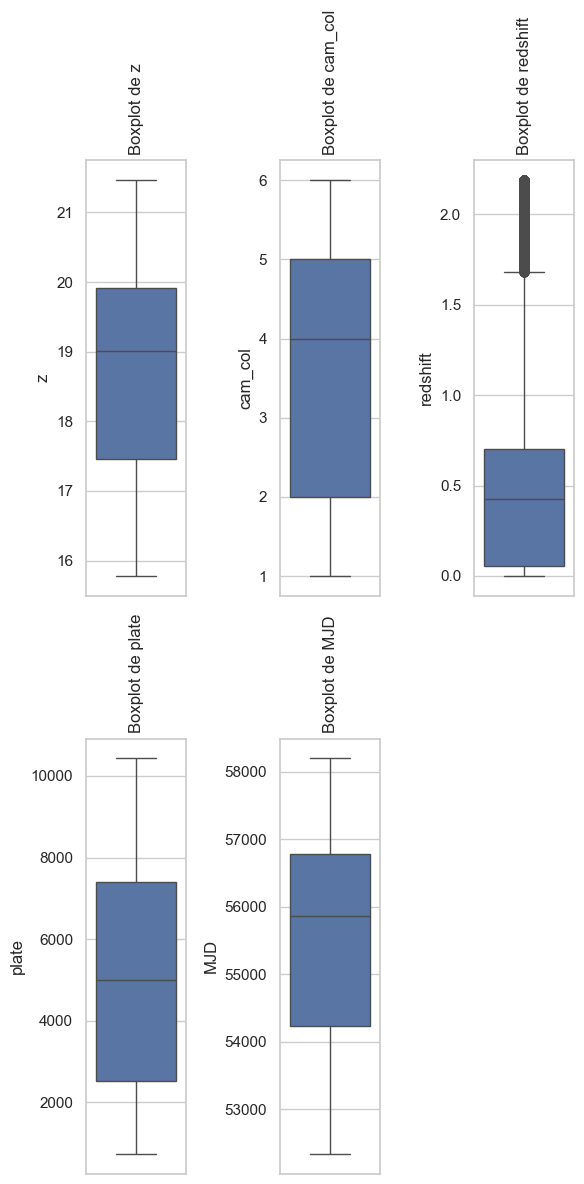

In [90]:
# Verificando a presença de outliers na distibuição do dataset
# após a aplicação da técnica de winsorização. 

boxplot(
    dataset = X_winsorized, 
    style   = boxplot_parameters["style"], 
    height  = boxplot_parameters["height"], 
    width   = boxplot_parameters["width"]
)

Nota-se que após a implementação de winsorização, a presença de outliers deixou de existir na maior parte das features com a exceção da feature de redshift, o que pode indicar que a sua distribuição ainda seja bastante assimétrica, fazendo com que mantenha-se a presença de dados outliers. Contudo, apesar disso, pode-se verificar uma redução da quantidade de outliers, frente ao que antes havia da winsorização. 


### Normalização 📏

A utilização de um *scaler* se faz necessário para preparar o dataset numa mesma escala, buscando auxiliar a capacidade de ajuste do modelo, que de outro modo poderia ser prejudicada pelos dados estarem em escalas diferentes. 

In [91]:
SEED = 115

In [101]:
# Criando um novo dataset com as features "winsorizadas"

df = pd.concat([X_winsorized, df_raw["class"]], axis=1)

In [102]:
df.head(5)

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD,class
0,135.689107,32.494632,23.87882,22.275300,20.395010,19.165730,18.793710,2,0.634794,5812,56354.0,GALAXY
1,144.826101,31.274185,24.77759,22.831880,22.070249,21.168120,21.462771,5,0.779136,10431,58158.0,GALAXY
2,142.188790,35.582444,25.26307,22.663890,20.609760,19.348570,18.948270,2,0.644195,4576,55592.0,GALAXY
3,338.741038,-0.402828,22.13682,23.408262,21.611620,20.504540,19.250100,3,0.932346,9149,58039.0,GALAXY
4,345.282593,21.183866,19.43718,17.580280,16.497470,16.043819,15.778155,3,0.116123,6121,56187.0,GALAXY


In [135]:
""" 
Por conta do fenômeno conhecido como data linkage é recomendado que antes da
normalização dos dados esses sejam submetidos à segmentação, para que informações
que poderiam estar contida em teste não vazem para os dados de treino, interferindo
no real ajuste do modelo, introduzindo muito mais um otimismo enquanto a sua avaliação
do que de fato ele estaria performando sem esse vazamento dos dados. 
"""


X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size    = 0.2, 
    random_state = SEED, 
    shuffle      = True
)

In [136]:
standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.fit_transform(X_test)

label_encoder = LabelEncoder()

df["class"] = label_encoder.fit_transform(df["class"])
y = df["class"]

### Random Forest 


In [137]:
"""
Instanciando o modelo de Random Forest, responsável por realizar 
a classificação dos dados em relação às classes apreciadas. 

Importante salientar que o objetivo principal desse notebook 
não é de eleaborar o modelo mais otimizado aos dados. Nesse sentido, 
apenas estou informando os hiperparâmetros que, de forma geral, são
responsáveis por formar um modelo que oferece um bom ajuste aos dados, 
sem que sofra overfitting.  

Por conta da natureza desbalanceadas das classes do dataset, escolhi
como critério de segmentação das classes nos nodes a métrica entropia,
por conta de sua maior sensibilidade a heterogeneidade dessas. 
"""

random_forest = RandomForestClassifier(
    n_estimators     = 100, 
    criterion        = "entropy", 
    max_depth        = 10, 
    min_samples_leaf = 5, 
    random_state     = SEED
)

In [138]:
%%time

random_forest.fit(X_train_scaled, y_train)

f1_score_v1 = f1_score(y_test, random_forest.predict(X_test_scaled), average="weighted")

CPU times: total: 9.56 s
Wall time: 35.5 s


In [139]:
print(f"A qualidade do ajuste do modelo mensurado em f1-score é de: {f1_score_v1.round(3)}")

A qualidade do ajuste do modelo mensurado em f1-score é de: 0.974


### Verificando data drifit

Mensurando a métrica do modelo para os últimos 20k dados presentes no dataset. Essa segmentação busca representar o fênomeno de data drifit, que pode ser compreendido no primeiro momento pela redução da qualidade do modelo em sua predição, monitorada por meio da métrica utilizada. 

In [142]:
df_tail = df.tail(20000)

X_tail = df.drop("class", axis=1)

y_tail = df["class"]


f1_score_v2 = f1_score(y_tail, random_forest.predict(X_tail), average="weighted")

In [143]:
print(f"A qualidade do ajuste do modelo mensurado em f1-score é de : {f1_score_v2.round(3)}")

A qualidade do ajuste do modelo mensurado em f1-score é de : 0.644


Analisando a métrica encontrada com base na outra distribuição dos dados, pode-se supor que tais dados fazem parte de uma distribuição diferente da distribuição vista pelo modelo em sua etapa de ajuste (treinamento). A forma com a qual permite analisar se de fato está em cenário de data drifit é a realização de um teste de hipótese relacionado a ambas distribuições, comparando com aquela que o modelo se ajustou na etapa de treinamento e a outra que é passada para a realização de sua predição. 

### Teste de hipótese 🔬

Para a realização do teste de hipótese responsável por aferir se ambos os datasets fazem parte da mesma distribuição, será escolhido a estatística de teste-z, útil para comparar se duas distribuições são similares, com base na média dos dados nelas presentes. Assim, caso ambas apresentam a média dos dados equivalente, tem-se que são similares e podem ser compreendidas como conjuntos de mesma distribuição (hipótese nula). Caso contrário, não (hipótese alternativa), denotando a presença de data drifit, recomendando-se o retreinamento do modelo aos novos dados. 

O teste-z é recomendado em cenários nos quais a quantidade de amostras é pelo menos maior do que 30 e quando há a disposição do desvio padrão populacional. Caso não dispõe-se de uma quantidade de amostra maior do que 30 e/ou do desvio padrão, pode ser útil o teste-t. É importante, salientar, que existem mais de um tipo estatística de teste e a sua escolha depende necessariamente do contexto do teste e da natureza dos dados presentes. 

A fórmula da estatística de teste pode ser compreendida da seguinte forma :


$$
Z = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

Em que :

- X1 e X2 representam as médias amostrais
- s²1 e s²2 são as variâncias amostrais
- n1 e n2 são os tamanhos amostrais


In [130]:
# Função que realiza o cálculo do teste-z, permitindo compreender, 
# com um intervalo de confiança de 95% se dois conjuntos de dados
# fazem ou não parte da mesma distribuição. 

def test_z(data_1: DataFrame, data_2: DataFrame) -> str:
    """
    Performs a two-sample Z-test to compare whether two datasets come from the same distribution.

    The function calculates the Z-score and p-value for the hypothesis test:
    - Null hypothesis (H0): The two datasets have the same mean.
    - Alternative hypothesis (H1): The means are different.

    Parameters:
        data_1 (DataFrame): First dataset, assumed to be numerical.
        data_2 (DataFrame): Second dataset, assumed to be numerical.

    Returns:
        str: A message indicating whether H0 is rejected or not, along with the computed p-value.
    """
    # Ensure the DataFrames have the same number of columns
    if data_1.shape[1] != data_2.shape[1]:
        raise ValueError("Both datasets must have the same number of columns.")
    
    # Iterate over each column for comparison
    for col_1, col_2 in zip(data_1.columns, data_2.columns):
        # Calculate means, variances, and sample sizes for each column
        mean_1, mean_2 = np.mean(data_1[col_1]), np.mean(data_2[col_2])
        var_1, var_2 = np.var(data_1[col_1], ddof=1), np.var(data_2[col_2], ddof=1)
        n_1, n_2 = len(data_1[col_1]), len(data_2[col_2])

        # Calculate Z-score for the column
        z = (mean_1 - mean_2) / np.sqrt(var_1 / n_1 + var_2 / n_2)

        # Calculate p-value for a two-tailed test
        p_value = 2 * (1 - norm.cdf(abs(z)))

        # Output results based on p-value
        print(f"Column: {col_1} vs {col_2}")
        if p_value < 0.05:
            print(f"Rejeita-se Ho : as disitribuições são diferentes\nValor-p encontrado : {round(p_value, 4)}\n")
        else:
            print(f"Aceita Ho : não há evidências estatísticas para afirmar que as distribuições são diferentes\nValor-p encontrado : {round(p_value, 4)}\n")
        

In [144]:
data_1 = pd.DataFrame(X_test_scaled, columns=df.drop("class", axis=1).columns)
data_2 = X_tail

In [145]:
# Verificando a distribuição de data_1. 
data_1.head(5)

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD
0,0.480413,-0.673454,-0.744448,-1.084476,-1.287959,-1.307960,-1.358718,-0.328600,-0.653879,-1.181398,-0.999443
1,0.249340,0.693936,-0.155256,0.252110,0.744871,0.960364,1.074605,1.565894,0.204768,1.312251,1.243271
2,-1.346671,-1.262107,-1.346954,-1.375313,-1.294892,-1.267043,-1.176908,0.302898,-0.782583,-1.525890,-1.844745
3,-0.664882,-0.050121,1.038617,0.932681,0.728334,0.411060,0.221901,-0.328600,-0.891070,-0.222114,-0.000664
4,-1.460545,-1.141730,1.408562,1.280587,0.671813,0.421093,0.294239,0.934396,-0.091416,-0.294914,-0.048333


In [ ]:
# Verificando a distribuição de data_2. 

"""
Nota-se que ambas as distribuições são diferentes entre si, fundamentalmente por 
conta da primeira estar normalizada, enquanto a segunda não. Para conceber um dataset
com dados que pudessem ser compreendidos como de distribuição diferentes, poderia 
ser utilizado, de fato, dados de uma outra distribuição, ou utilizar-se de técnicas
de modificação aleatória nas features ou nas labels do presente dataset. 

A forma escolhida para o presente notebook foi simplesmente selecionar os últimos
20k dados presentes no dataset e não normalizá-los, antes de os passar para o modelo, 
produzindo uma queda na sua qualidade de predição - o que poderia aludir a presença de 
data drifit - e criando uma simulação de dataset que faz parte de uma distribuição 
diferente, o qual será comparado com dados da mesma distribuição vista durante 
o ajuste do modelo em um teste de hipótese, com estatística de teste-z. 
"""

data_2.head(5)

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD
0,135.689107,32.494632,23.87882,22.275300,20.395010,19.165730,18.793710,2,0.634794,5812,56354.0
1,144.826101,31.274185,24.77759,22.831880,22.070249,21.168120,21.462771,5,0.779136,10431,58158.0
2,142.188790,35.582444,25.26307,22.663890,20.609760,19.348570,18.948270,2,0.644195,4576,55592.0
3,338.741038,-0.402828,22.13682,23.408262,21.611620,20.504540,19.250100,3,0.932346,9149,58039.0
4,345.282593,21.183866,19.43718,17.580280,16.497470,16.043819,15.778155,3,0.116123,6121,56187.0


In [134]:
test_z(
    data_1=data_1, 
    data_2=data_2
)

Column: alpha vs alpha
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: delta vs delta
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: u vs u
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: g vs g
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: r vs r
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: i vs i
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: z vs z
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: cam_col vs cam_col
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: redshift vs redshift
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: plate vs plate
Rejeita-se Ho : as disitribuições são diferentes
Valor-p encontrado : 0.0

Column: MJD vs MJD
Rejeita-se Ho : as disitribuiçõ